# Selecting the collagen features that matter

You now have a feature table — one row per **normal** core, ~35 collagen measurements per row. Many of those measurements secretly capture the *same* thing (e.g. several Gabor filters, or fiber-area and skeleton-length). This notebook finds the **redundant families** and picks **one representative per family**, giving a short, non-redundant feature list.

1. **Load** the normal-core feature table.
2. **Standardize** the features so they're comparable.
3. **Correlate & cluster** them — this is the heatmap; redundant features form blocks.
4. **Cut the clustering into families** and **pick one representative** per family.
5. **Save** two tables: the full features and the concise (selected) features — both `TMA_ID`-first, ready to join to the clinical/survival data in R.

> **Note:** this is *unsupervised* selection — we choose features because they capture collagen structure, **not** because they predict survival. That separation is deliberate: it keeps the survival test honest later.

> **Honest caveat:** with only a few cores this is a demonstration of the machinery. It becomes a real result once all ~59 normal cores are in the table.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler


## 1. Load the feature table

This reads the CSV the batch script produced (`features_full_normal.csv`). The first two columns are `TMA_ID` and `Status`; everything else is a feature.


In [2]:
df = pd.read_csv("Features/features_full_normal.csv")
print("Table shape:", df.shape, "(rows = cores, columns = id + status + features)")

# separate the id/status columns from the numeric features
meta_cols = ["TMA_ID", "Status"]
feature_cols = [c for c in df.columns if c not in meta_cols]
X = df[feature_cols]

print(f"{len(df)} cores, {len(feature_cols)} features")
if len(df) < 5:
    print("\n*** Only", len(df), "core(s) so far. The steps below RUN, but the")
    print("    families/selection are only trustworthy with many cores. ***")
df.head()


Table shape: (3, 37) (rows = cores, columns = id + status + features)
3 cores, 35 features

*** Only 3 core(s) so far. The steps below RUN, but the
    families/selection are only trustworthy with many cores. ***


,TMA_ID,Status,area_fraction,porosity,collagen_mean,collagen_median,collagen_sd,gabor_t0_f0.04_mean,gabor_t0_f0.04_var,gabor_t0_f0.08_mean,...,gabor_t135_f0.08_mean,gabor_t135_f0.08_var,gabor_t135_f0.12_mean,gabor_t135_f0.12_var,meij_fiber_area,meij_skeleton_len,sato_fiber_area,sato_skeleton_len,alignment_coherence,dominant_orientation_rad
0,1_005_01-S-16-07206,normal,26.297934,0.737021,0.371354,0.20,0.227976,0.114802,0.009649,0.078207,...,0.075266,0.003530,0.059856,0.001929,0.202424,37666.0,0.198544,60157.0,0.200991,0.233155
1,1_015_01-S-15-15501,normal,4.595372,0.954046,0.680133,0.50,0.239497,0.099420,0.010620,0.065752,...,0.064651,0.003245,0.049848,0.001464,0.051304,9747.0,0.054654,14194.0,0.190658,-0.102253
2,1_019_01-SU-02-06239,normal,24.477769,0.755222,0.386914,0.35,0.236587,0.117671,0.009452,0.082522,...,0.079520,0.003570,0.063999,0.002105,0.208889,39007.0,0.213510,61165.0,0.203007,0.005125


## 2. Standardize the features

Each feature is in different units (a percentage, a pixel count, a 0–1 value). We z-score every column — subtract its mean, divide by its standard deviation — so no feature dominates just because its numbers are bigger.


In [3]:
Xs = pd.DataFrame(
    StandardScaler().fit_transform(X),
    index=df["TMA_ID"], columns=feature_cols
)
Xs.head()


,area_fraction,porosity,collagen_mean,collagen_median,collagen_sd,gabor_t0_f0.04_mean,gabor_t0_f0.04_var,gabor_t0_f0.08_mean,gabor_t0_f0.08_var,gabor_t0_f0.12_mean,...,gabor_t135_f0.08_mean,gabor_t135_f0.08_var,gabor_t135_f0.12_mean,gabor_t135_f0.12_var,meij_fiber_area,meij_skeleton_len,sato_fiber_area,sato_skeleton_len,alignment_coherence,dominant_orientation_rad
TMA_ID,,,,,,,,,,,,,,,,,,,,,
1_005_01-S-16-07206,0.797668,-0.797668,-0.761175,-1.224745e+00,-1.371868,0.520507,-0.504887,0.381616,0.853690,0.394966,...,0.339120,0.561565,0.329153,0.354852,0.662244,0.656814,0.600045,0.683977,0.512511,1.342943
1_015_01-S-15-15501,-1.410167,1.410167,1.412798,1.224745e+00,0.983395,-1.399027,1.396479,-1.370120,-1.403272,-1.373494,...,-1.358571,-1.404830,-1.355687,-1.362989,-1.413284,-1.413048,-1.409058,-1.413964,-1.397745,-1.055371
1_019_01-SU-02-06239,0.612499,-0.612499,-0.651623,4.532467e-16,0.388474,0.878520,-0.891592,0.988504,0.549583,0.978527,...,1.019452,0.843265,1.026533,1.008137,0.751040,0.756234,0.809013,0.729987,0.885235,-0.287572


## 3. Correlate & cluster — the heatmap

We compute the correlation between **every pair of features** (−1 to +1), then cluster so similar features sit together. Redundant features show up as **red blocks**. The side/legend colors tag each feature's **family** so you can see the families group together.


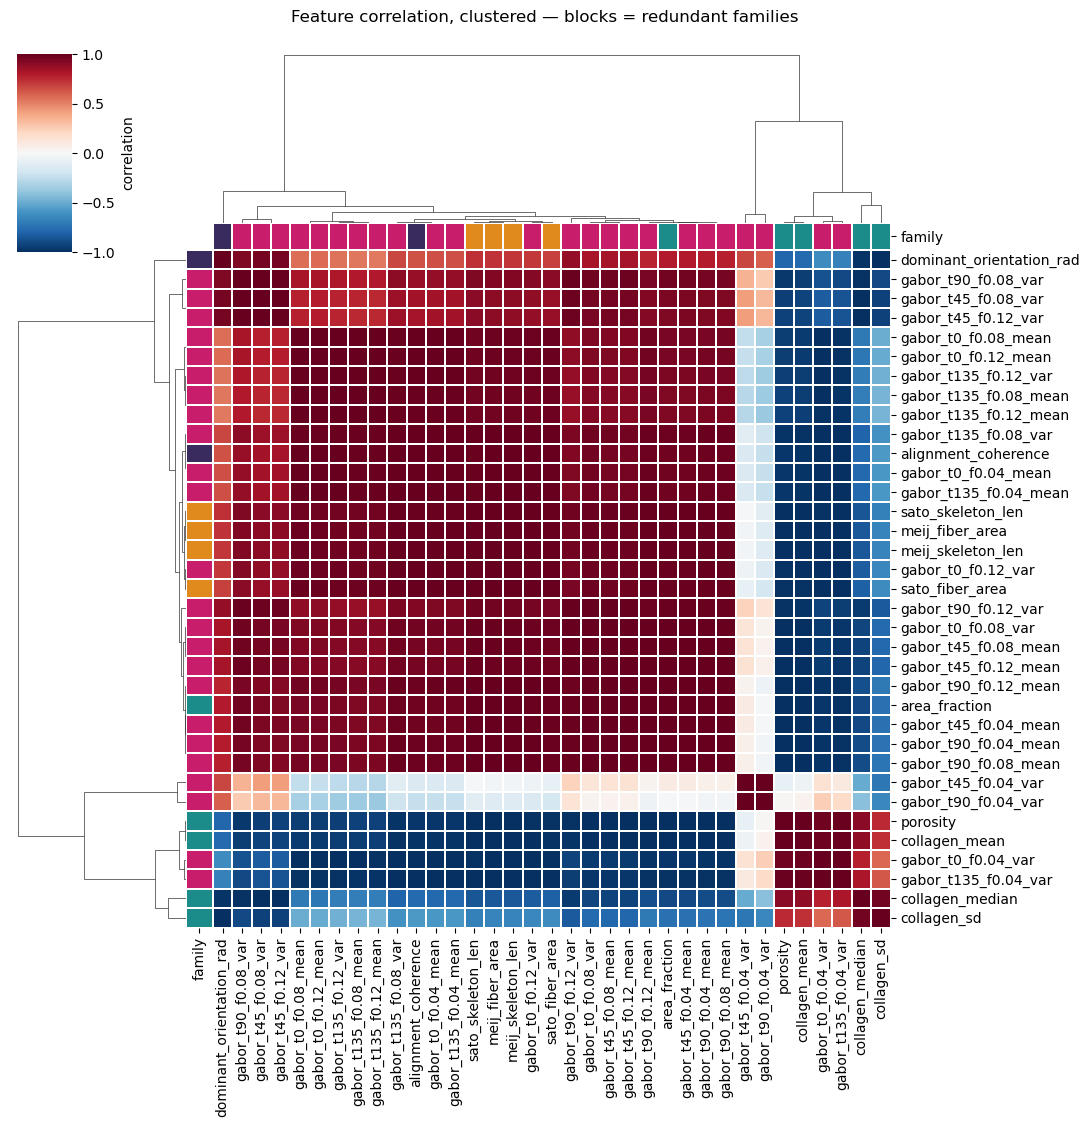

In [4]:
corr = Xs.corr(method="pearson")   # 35 x 35 pairwise correlations (Pearson, matches the team)

# tag each feature with a family (for the colored side bars)
def family(c):
    if c.startswith("gabor"):                                   return "Texture (Gabor)"
    if c in ["area_fraction","porosity","collagen_mean",
             "collagen_median","collagen_sd"]:                  return "Density / intensity"
    if "skeleton" in c or "fiber" in c:                         return "Fiber network"
    if "coherence" in c or "orientation" in c:                  return "Alignment"
    return "Other"

fam_colors = {"Density / intensity":"#1C8C8A", "Texture (Gabor)":"#C81D6B",
              "Fiber network":"#E08A1E", "Alignment":"#3A2B5F", "Other":"#999999"}
col_colors = pd.Series({c: fam_colors[family(c)] for c in corr.columns}, name="family")

g = sns.clustermap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
                   figsize=(11,11), linewidths=0.3, linecolor="white",
                   row_colors=col_colors, col_colors=col_colors,
                   cbar_kws={"label":"correlation"})
g.fig.suptitle("Feature correlation, clustered — blocks = redundant families", y=1.02)
plt.show()


## 4. Cut the clustering into families & pick representatives

We cut the feature clustering tree into a handful of groups. Each group is a **family** of features that move together. From each family we keep the **one feature most representative** of the group (the one most correlated, on average, with its family-mates) — that's the concise feature set.

Change `N_FAMILIES` to control how many groups you split into.


In [6]:
N_FAMILIES = 6   # how many families to split the features into (tune this)

# cluster the FEATURES using correlation as the distance
dist = 1 - corr.abs()                      # highly-correlated -> small distance
dist = dist.clip(lower=0)                   # guard against tiny negative rounding errors
np.fill_diagonal(dist.values, 0)            # a feature's distance to itself is exactly 0
Z = linkage(squareform(dist.values, checks=False), method="average")
labels = fcluster(Z, t=N_FAMILIES, criterion="maxclust")

groups = {}
for feat, lab in zip(corr.columns, labels):
    groups.setdefault(lab, []).append(feat)

# pick the representative of each family = feature with highest mean |corr| to its group
selected = []
print("Families found:\n")
for lab, feats in sorted(groups.items()):
    if len(feats) == 1:
        rep = feats[0]
    else:
        sub = corr.loc[feats, feats].abs()
        rep = sub.mean(axis=1).idxmax()
    selected.append(rep)
    fams = {family(f) for f in feats}
    print(f"  Family {lab} ({', '.join(fams)}): {len(feats)} features -> keep '{rep}'")

print("\nSelected (concise) features:", selected)

Families found:

  Family 1 (Texture (Gabor)): 2 features -> keep 'gabor_t45_f0.04_var'
  Family 2 (Texture (Gabor), Density / intensity): 11 features -> keep 'gabor_t45_f0.04_mean'
  Family 3 (Texture (Gabor)): 5 features -> keep 'gabor_t135_f0.12_var'
  Family 4 (Texture (Gabor), Fiber network, Alignment): 11 features -> keep 'gabor_t135_f0.04_var'
  Family 5 (Alignment, Density / intensity): 2 features -> keep 'collagen_sd'
  Family 6 (Texture (Gabor), Density / intensity): 4 features -> keep 'gabor_t45_f0.12_var'

Selected (concise) features: ['gabor_t45_f0.04_var', 'gabor_t45_f0.04_mean', 'gabor_t135_f0.12_var', 'gabor_t135_f0.04_var', 'collagen_sd', 'gabor_t45_f0.12_var']


## 5. Save the two tables for R

Both tables keep `TMA_ID` first so they join cleanly to the clinical/survival metadata in the experiment object. One is the **full** feature set, one is the **concise** (selected) set.


In [7]:
# full table (already TMA_ID-first from the batch script)
df.to_csv("Features/features_full_normal.csv", index=False)

# concise table = TMA_ID + Status + the selected representative features
concise = df[["TMA_ID", "Status"] + selected]
concise.to_csv("Features/features_concise_normal.csv", index=False)

print("Wrote:")
print("  Features/features_full_normal.csv    ", df.shape)
print("  Features/features_concise_normal.csv ", concise.shape)
concise.head()


Wrote:
  Features/features_full_normal.csv     (3, 37)
  Features/features_concise_normal.csv  (3, 8)


,TMA_ID,Status,gabor_t45_f0.04_var,gabor_t45_f0.04_mean,gabor_t135_f0.12_var,gabor_t135_f0.04_var,collagen_sd,gabor_t45_f0.12_var
0,1_005_01-S-16-07206,normal,0.009616,0.115891,0.001929,0.009270,0.227976,0.002477
1,1_015_01-S-15-15501,normal,0.009321,0.093236,0.001464,0.010367,0.239497,0.001125
2,1_019_01-SU-02-06239,normal,0.009030,0.113952,0.002105,0.009137,0.236587,0.001908
